In [54]:
import pandas as pd
import matplotlib.pyplot as plt
from glob import glob
import os
import json
import numpy as np

In [74]:
files = glob(r"..\data\CO2Dot\260619 dye CO2 response\*.json")
files

['..\\data\\CO2Dot\\260619 dye CO2 response\\2026-06-18_11-59-45_co2Periods_Dye.json',
 '..\\data\\CO2Dot\\260619 dye CO2 response\\2026-06-19_13-01-38_co2response.json']

In [75]:
file = files[-1]
with open(file, "r") as f:
        data = json.load(f)
        try:
            metadata = {
                "experiment_start": data["experiment_start"],
                "co2_concentration": data["co2_s_values"],
                "stabilise_tol": data["stabilise_tol"],
                "stabilise_timeout": data["stabilise_timeout_s"],
                "extra_wait_s": data["extra_wait_s"],
                "experiment_end": data["experiment_end"]
            }
                    
        except Exception as e:
            print(f"Error processing file {file}: {e}")

        df = pd.DataFrame(data["records"])
        df["timestamp"] = pd.to_datetime(df["timestamp"])

Error processing file ..\data\CO2Dot\260619 dye CO2 response\2026-06-19_13-01-38_co2response.json: 'stabilise_tol'


In [76]:
    
    df


,timestamp,co2_s_setpoint,note,licor,co2dot,temp,rh,rep,measurement
0,2026-06-19 13:04:38,300,,"{'TIME': 1782126420.6, 'DIAG': 18, 'CO2_s': 39...",{'status': {'spectrometer': {'model': 'AS7341'...,17,40,0,0
1,2026-06-19 13:04:59,300,,"{'TIME': 1782126442.1, 'DIAG': 18, 'CO2_s': 28...",{'status': {'spectrometer': {'model': 'AS7341'...,17,40,0,1
2,2026-06-19 13:05:21,300,,"{'TIME': 1782126463.6, 'DIAG': 18, 'CO2_s': 24...",{'status': {'spectrometer': {'model': 'AS7341'...,17,40,0,2
3,2026-06-19 13:05:42,300,,"{'TIME': 1782126485.1, 'DIAG': 18, 'CO2_s': 25...",{'status': {'spectrometer': {'model': 'AS7341'...,17,40,0,3
4,2026-06-19 13:06:04,300,,"{'TIME': 1782126506.6, 'DIAG': 18, 'CO2_s': 25...",{'status': {'spectrometer': {'model': 'AS7341'...,17,40,0,4
...,...,...,...,...,...,...,...,...,...
158,2026-06-19 13:54:53,500,,"{'TIME': 1782129436, 'DIAG': 18, 'CO2_s': 511....",{'status': {'spectrometer': {'model': 'AS7341'...,17,70,0,2
159,2026-06-19 13:55:15,500,,"{'TIME': 1782129457.5, 'DIAG': 18, 'CO2_s': 51...",{'status': {'spectrometer': {'model': 'AS7341'...,17,70,0,3
160,2026-06-19 13:55:36,500,,"{'TIME': 1782129479, 'DIAG': 18, 'CO2_s': 510....",{'status': {'spectrometer': {'model': 'AS7341'...,17,70,0,4
161,2026-06-19 13:55:58,500,,"{'TIME': 1782129500.5, 'DIAG': 18, 'CO2_s': 51...",{'status': {'spectrometer': {'model': 'AS7341'...,17,70,0,5


In [77]:
# Expand the dict-valued "licor" and "co2dot" columns into flat columns.
# licor is a flat dict; co2dot is nested (status / spec_flash / env) -> flatten with sep="_".
# Prefixes keep names unique (e.g. licor_CO2_s vs co2_s_setpoint) and mark provenance.
licor_expanded = pd.json_normalize(df["licor"], sep="_").add_prefix("licor_")
co2dot_expanded = pd.json_normalize(df["co2dot"], sep="_").add_prefix("co2dot_")

df = pd.concat(
    [
        df.drop(columns=["licor", "co2dot"]).reset_index(drop=True),
        licor_expanded.reset_index(drop=True),
        co2dot_expanded.reset_index(drop=True),
    ],
    axis=1,
)
df

,timestamp,co2_s_setpoint,note,temp,rh,rep,measurement,licor_TIME,licor_DIAG,licor_CO2_s,...,co2dot_spec_flash_diff_f5_555,co2dot_spec_flash_diff_f6_590,co2dot_spec_flash_diff_f7_630,co2dot_spec_flash_diff_f8_680,co2dot_spec_flash_diff_clear,co2dot_spec_flash_diff_nir,co2dot_env_T,co2dot_env_P,co2dot_env_RH,co2dot_env_Gas
0,2026-06-19 13:04:38,300,,17,40,0,0,1.782126e+09,18,394.838,...,3870,3769,3909,5028,4779,435,20.17,1013.81,40.97,6627
1,2026-06-19 13:04:59,300,,17,40,0,1,1.782126e+09,18,282.502,...,3840,3725,3850,4973,4738,432,20.10,1013.77,39.40,11451
2,2026-06-19 13:05:21,300,,17,40,0,2,1.782126e+09,18,247.230,...,3785,3655,3769,4907,4675,427,20.05,1013.78,38.60,16447
3,2026-06-19 13:05:42,300,,17,40,0,3,1.782126e+09,18,253.740,...,3777,3644,3753,4892,4663,426,19.97,1013.78,38.33,20689
4,2026-06-19 13:06:04,300,,17,40,0,4,1.782127e+09,18,252.974,...,3776,3643,3751,4889,4662,426,19.88,1013.74,38.37,24229
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
158,2026-06-19 13:54:53,500,,17,70,0,2,1.782129e+09,18,511.474,...,3664,3592,3886,5174,4710,431,19.53,1013.59,61.76,55711
159,2026-06-19 13:55:15,500,,17,70,0,3,1.782129e+09,18,510.094,...,3675,3605,3901,5185,4721,432,19.54,1013.57,61.79,54836
160,2026-06-19 13:55:36,500,,17,70,0,4,1.782129e+09,18,510.094,...,3684,3616,3913,5194,4730,432,19.54,1013.62,61.82,54550
161,2026-06-19 13:55:58,500,,17,70,0,5,1.782130e+09,18,510.036,...,3690,3623,3921,5200,4736,433,19.53,1013.53,61.87,54127


Text(0.5, 1.0, 'Comparison Licor vs CO2Dot')

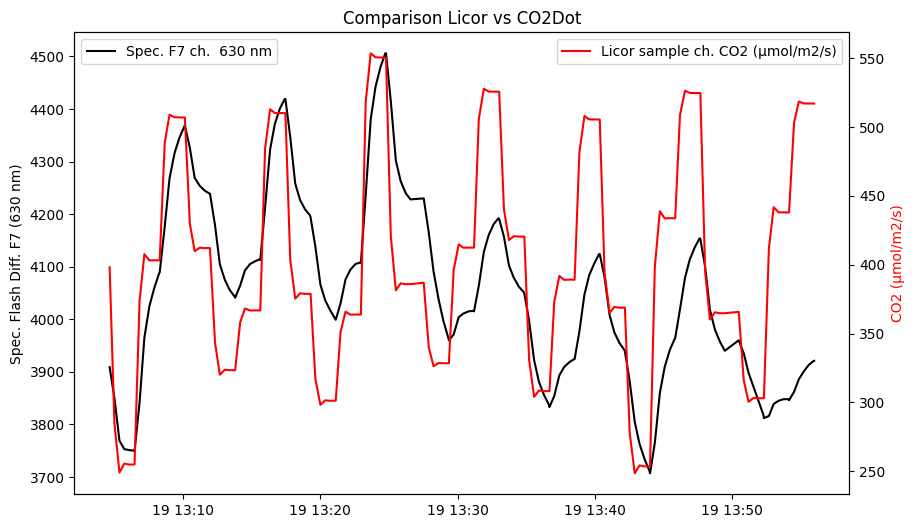

In [78]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(df["timestamp"], df["co2dot_spec_flash_diff_f7_630"],color="k", label="Spec. F7 ch.  630 nm")
ax2 = ax.twinx()
ax2.plot(df["timestamp"], df["licor_CO2_s_d"], color="r", label="Licor sample ch. CO2 (µmol/m2/s)")
ax.legend(loc="upper left")
ax2.legend(loc="upper right")
plt.xlabel("Time")
ax.set_ylabel("Spec. Flash Diff. F7 (630 nm)",color="k")
ax2.set_ylabel("CO2 (µmol/m2/s)",color="r")
plt.title("Comparison Licor vs CO2Dot")

Text(0.5, 1.0, 'Environmental conditions during measurement')

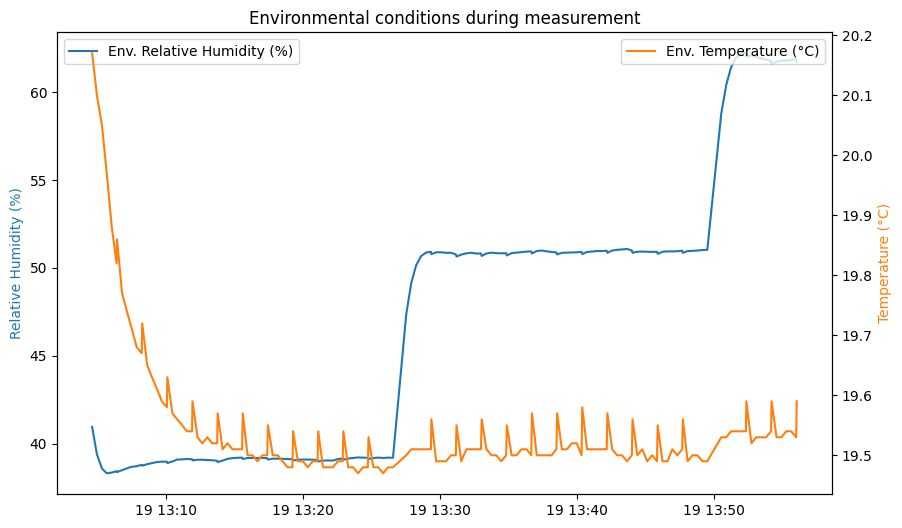

In [79]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(df["timestamp"], df["co2dot_env_RH"],color="C00", label="Env. Relative Humidity (%)")
ax2 = ax.twinx()
ax2.plot(df["timestamp"], df["co2dot_env_T"], color="C01", label="Env. Temperature (°C)")
ax.legend(loc="upper left")
ax2.legend(loc="upper right")
plt.xlabel("Time")
ax.set_ylabel("Relative Humidity (%)",color="C00")
ax2.set_ylabel("Temperature (°C)",color="C01")
plt.title("Environmental conditions during measurement")

Total samples: 56
Training samples: 44, Testing samples: 12
Linear regression
  MAE : 3.116
  RMSE: 4.333
  R^2 : 0.9948
Coefficients: {'X1': np.float64(-1.290928356973538), 'X2': np.float64(1.9394916271778684)}
Intercept: 22624.329553683845


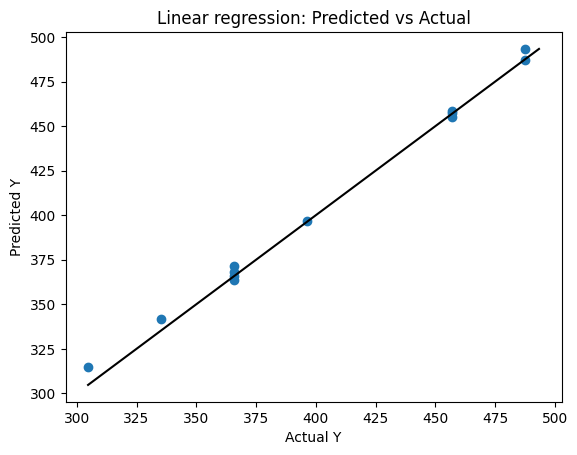

In [65]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

X = df[["co2dot_spec_flash_diff_f1_415","co2dot_spec_flash_diff_f2_445","co2dot_spec_flash_diff_f3_480","co2dot_spec_flash_diff_f4_515","co2dot_spec_flash_diff_f5_555","co2dot_spec_flash_diff_f6_590","co2dot_spec_flash_diff_f7_630","co2dot_spec_flash_diff_f8_680","co2dot_spec_flash_diff_clear","co2dot_spec_flash_diff_nir","co2dot_env_T","co2dot_env_P","co2dot_env_RH","co2dot_env_Gas"]]
y = df["licor_CO2_s_d"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Total samples:", len(X))
print(f"Training samples: {len(X_train)}, Testing samples: {len(X_test)}")

# ---- Model ----
lin = LinearRegression()
lin.fit(X_train, y_train)

# ---- Predict + metrics ----
pred = lin.predict(X_test)

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print("Linear regression")
print(f"  MAE : {mae:.4g}")
print(f"  RMSE: {rmse:.4g}")
print(f"  R^2 : {r2:.4g}")
print("Coefficients:", dict(zip(["X1", "X2"], lin.coef_)))
print("Intercept:", lin.intercept_)

plt.figure()
plt.scatter(y_test, pred)
lims = [min(y_test.min(), pred.min()), max(y_test.max(), pred.max())]
plt.plot(lims, lims,"k")  # y=x reference
plt.xlabel("Actual Y")
plt.ylabel("Predicted Y")
plt.title("Linear regression: Predicted vs Actual")
plt.show()
